In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt

## WM_811K Dataset Class

In [2]:
from datasets import WM_811K
wm811k = WM_811K(imsize=(96,96))

reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

## 1. Train Segmentation Model

In [3]:
# create segmentation model with U-Net like architecture
def create_segmentation_model():
    def conv_block(x, f, pad='valid', halve=True):
        if halve:
            x = tf.keras.layers.MaxPooling2D((2,2))(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2D(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        return x

    def deconv_block(xA, xB, f, pad='valid', double=True):
        x = tf.keras.layers.Concatenate(axis=-1)([xA,xB])
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Conv2DTranspose(f, (3,3), activation='relu', padding=pad)(x)
        x = tf.keras.layers.Dropout(0.25)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        if double:
            x = tf.keras.layers.Conv2DTranspose(f//2, (2,2), activation='relu', strides=(2,2))(x)
        return x

    img_input = tf.keras.layers.Input(shape=(*wm811k.imsize, 1))

    # encoder blocks
    x1 = conv_block(img_input, 32, 'same', False)
    x2 = conv_block(x1, 64)
    x3 = conv_block(x2, 128)
    x4 = conv_block(x3, 256)

    # dense block
    x5 = tf.keras.layers.GlobalAveragePooling2D()(x4)
    x5 = tf.keras.layers.Dense(1024)(x5)
    x5 = tf.keras.layers.Dropout(0.5)(x5)
    x5 = tf.keras.layers.Dense(256)(x5)
    x5 = tf.keras.layers.Dropout(0.5)(x5)
    x5 = tf.keras.layers.Reshape((1,1,256))(x5)
    x5 = tf.keras.layers.Conv2DTranspose(64, (5,5), activation='relu')(x5)

    # decoder blocks
    x6 = deconv_block(x4, x5, 128)
    x7 = deconv_block(x3, x6, 128)
    x8 = deconv_block(x2, x7, 64)
    x9 = deconv_block(x1, x8, 32, 'same', False)

    imgs_output = tf.keras.layers.Conv2D(WM_811K.n_classes-1, (3,3), activation='sigmoid', padding='same')(x9)
    return tf.keras.Model(inputs=img_input, outputs=imgs_output, name='segmentation_model')


model_segmentation = create_segmentation_model()
model_segmentation.compile(
    loss=tf.keras.losses.MSE,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)
model_segmentation.summary()

Model: "segmentation_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 96, 96,    │          0 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        128 │ dropout[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 46, 46,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 44, 44,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 44, 44,    │          0 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │        256 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 20,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 18, 18,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 18, 18,    │          0 │ conv2d_5[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 18,    │        512 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 9, 9, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 256) │    295,168 │ max_pooling2d_2[

 Total params: 3,210,120 (12.25 MB)

 Trainable params: 3,208,456 (12.24 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [4]:
ds_train = wm811k.dataset_multi_defect_segmentation().batch(16).prefetch(tf.data.AUTOTUNE)

In [5]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_segmentation.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

history = model_segmentation.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.2079
Epoch 1: loss improved from None to 0.14598, saving model to ../models/multi_defect_segmentation.keras

Epoch 1: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - loss: 0.1460
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0499
Epoch 2: loss improved from 0.14598 to 0.04249, saving model to ../models/multi_defect_segmentation.keras

Epoch 2: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0425
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0340
Epoch 3: loss improved from 0.04249 to 0.03313, saving model to ../models/multi_defect_segmentation.keras

Epoch 3: finished saving model to ../models/multi_defect_segmentation.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - loss: 0.0331
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0274
Epoch 4: loss improved from 0.03313 to 0

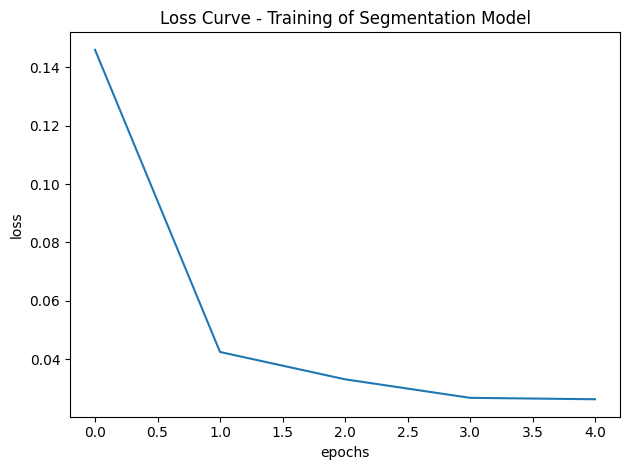

In [6]:
plt.plot(history.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Loss Curve - Training of Segmentation Model')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'segmentation_loss_curve.png'))

## 2. Pretrain Classification Model

In [7]:
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        """
        kernel_size: 7x7 is the standard established by the CBAM paper. 
        It gives the convolution a wide enough receptive field to understand 
        the geometry around a pixel.
        """
        super(SpatialAttention, self).__init__(**kwargs)
        
        # The single convolution layer that creates the final mask
        self.conv = tf.keras.layers.Conv2D(
            filters=1, 
            kernel_size=kernel_size, 
            padding='same', 
            activation='sigmoid', 
            use_bias=False # Bias is unnecessary here
        )

    def call(self, inputs):
        # 1. Average Pooling across the channel axis (axis=-1)
        # Shape changes from (B, H, W, C) -> (B, H, W, 1)
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        
        # 2. Max Pooling across the channel axis
        # Shape changes from (B, H, W, C) -> (B, H, W, 1)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        
        # 3. Concatenate the two maps together
        # Shape becomes (B, H, W, 2)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        
        # 4. Pass through convolution and sigmoid to generate the mask
        # Shape becomes (B, H, W, 1), with values between 0.0 and 1.0
        attention_mask = self.conv(concat)
        
        # 5. Multiply the mask against the original inputs
        return inputs * attention_mask

    # Required so you can save and load your model later without errors
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        return config

model_classification = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(*wm811k.imsize,WM_811K.n_classes-1)),
                          
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # ---- Conv block 4 -------------------------------------------------
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    SpatialAttention(),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(WM_811K.n_classes-1, activation='sigmoid'),    
], name='classification_model')

model_classification.compile(
     loss=tf.keras.losses.BinaryCrossentropy(),
     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
     metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

model_classification.summary()


Model: "classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 94, 94, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention               │ (None, 94, 94, 32)     │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 94, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 94, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_1             │ (None, 45, 45, 64)     │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 45, 45, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_2             │ (None, 20, 20, 128)    │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_3             │ (None, 8, 8, 256)      │            98 │
│ (SpatialAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             

 Total params: 2,106,864 (8.04 MB)

 Trainable params: 2,103,344 (8.02 MB)

 Non-trainable params: 3,520 (13.75 KB)

In [8]:
model_fullstack = tf.keras.models.Sequential([
    model_segmentation,
    model_classification
], name='fullstack_model')

model_fullstack.layers[0].trainable = False     # freeze segmentation model
model_fullstack.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)
model_fullstack.summary()

Model: "fullstack_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ segmentation_model (Functional) │ (None, 96, 96, 8)      │     3,210,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_model            │ (None, 8)              │     2,106,864 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,316,984 (20.28 MB)

 Trainable params: 2,103,344 (8.02 MB)

 Non-trainable params: 3,213,640 (12.26 MB)

In [9]:
ds_train = wm811k.dataset_multi_defect_fullstack().batch(16).prefetch(tf.data.AUTOTUNE)

In [10]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=64,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - auc: 0.6346 - loss: 0.8970
Epoch 1: loss improved from None to 0.81008, saving model to ../models/multi_defect_fullstack.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 746ms/step - auc: 0.6745 - loss: 0.8101
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - auc: 0.6800 - loss: 0.6711
Epoch 2: loss improved from 0.81008 to 0.63534, saving model to ../models/multi_defect_fullstack.keras

Epoch 2: finished saving model to ../models/multi_defect_fullstack.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 707ms/step - auc: 0.6946 - loss: 0.6353
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - auc: 0.7043 - loss: 0.5672
Epoch 3: loss improved from 0.63534 to 0.54506, saving model to ../models/multi_defect_fullstack.keras

Epoch 3: finished saving model to ../models/multi_defect_fullstack.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 49s 762ms/step - auc: 0.7106 - loss: 0.5451
Epoch 4/5
64/64 ━━━

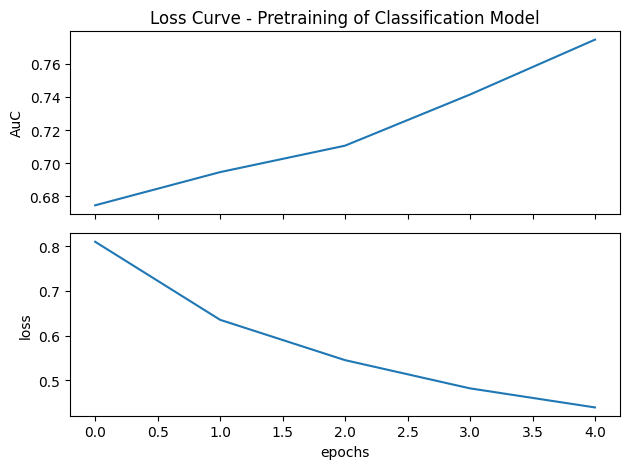

In [11]:
_,(ax1,ax2) = plt.subplots(2,1, sharex=True)
ax1.plot(history.history['auc'])
ax1.set_ylabel('AuC')
ax1.set_title('Loss Curve - Pretraining of Classification Model')
ax2.plot(history.history['loss'])
ax2.set_xlabel('epochs')
ax2.set_ylabel('loss')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'classification_pretrain_loss_curve.png'))

## 3. Fine-Tune Full Stack Model

In [12]:
model_fullstack.layers[0].trainable = True      # unfreeze segmentation model
#model_fullstack.compile(
#    loss=tf.keras.losses.BinaryCrossentropy(),
#    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),      # lower learning rate
#    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
#)
model_fullstack.summary()

Model: "fullstack_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ segmentation_model (Functional) │ (None, 96, 96, 8)      │     3,210,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_model            │ (None, 8)              │     2,106,864 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,523,674 (36.33 MB)

 Trainable params: 5,311,800 (20.26 MB)

 Non-trainable params: 5,184 (20.25 KB)

 Optimizer params: 4,206,690 (16.05 MB)

In [13]:
ds_train = wm811k.dataset_multi_defect_fullstack().batch(64).prefetch(tf.data.AUTOTUNE)

In [14]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join('..', 'models', 'multi_defect_fullstack.keras'),
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

history = model_fullstack.fit(
    x=ds_train,
    steps_per_epoch=16,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - auc: 0.8265 - loss: 0.3688
Epoch 1: loss improved from None to 0.36665, saving model to ../models/multi_defect_fullstack.keras

Epoch 1: finished saving model to ../models/multi_defect_fullstack.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - auc: 0.8290 - loss: 0.3667
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8387 - loss: 0.3616
Epoch 2: loss improved from 0.36665 to 0.36180, saving model to ../models/multi_defect_fullstack.keras

Epoch 2: finished saving model to ../models/multi_defect_fullstack.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - auc: 0.8381 - loss: 0.3618
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - auc: 0.8414 - loss: 0.3515
Epoch 3: loss improved from 0.36180 to 0.35220, saving model to ../models/multi_defect_fullstack.keras

Epoch 3: finished saving model to ../models/multi_defect_fullstack.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - auc: 0.8435 - loss: 0.3522
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 

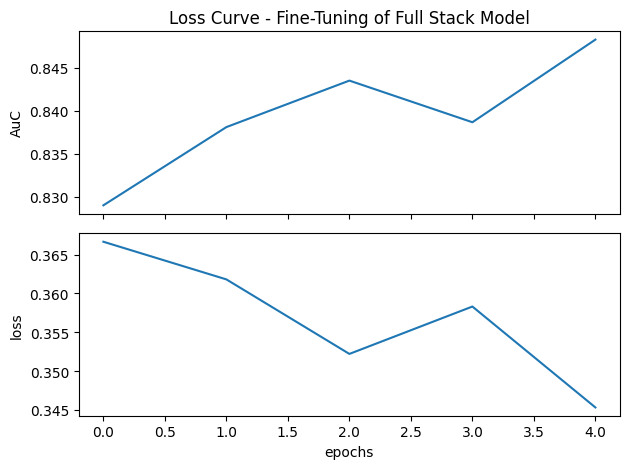

In [15]:
_,(ax1,ax2) = plt.subplots(2,1, sharex=True)
ax1.plot(history.history['auc'])
ax1.set_ylabel('AuC')
ax1.set_title('Loss Curve - Fine-Tuning of Full Stack Model')
ax2.plot(history.history['loss'])
ax2.set_xlabel('epochs')
ax2.set_ylabel('loss')
plt.tight_layout()
plt.savefig(os.path.join('..', 'plots', 'fullstack_loss_curve.png'))

## 4. Visualize Segmentation

In [16]:
model_segmentation = tf.keras.models.load_model(os.path.join('..', 'models', 'multi_defect_segmentation.keras'))

In [17]:
in_batch, out_batch = list(wm811k.dataset_multi_defect_segmentation().batch(32).take(1))[0]
pred_batch = model_segmentation.predict(in_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


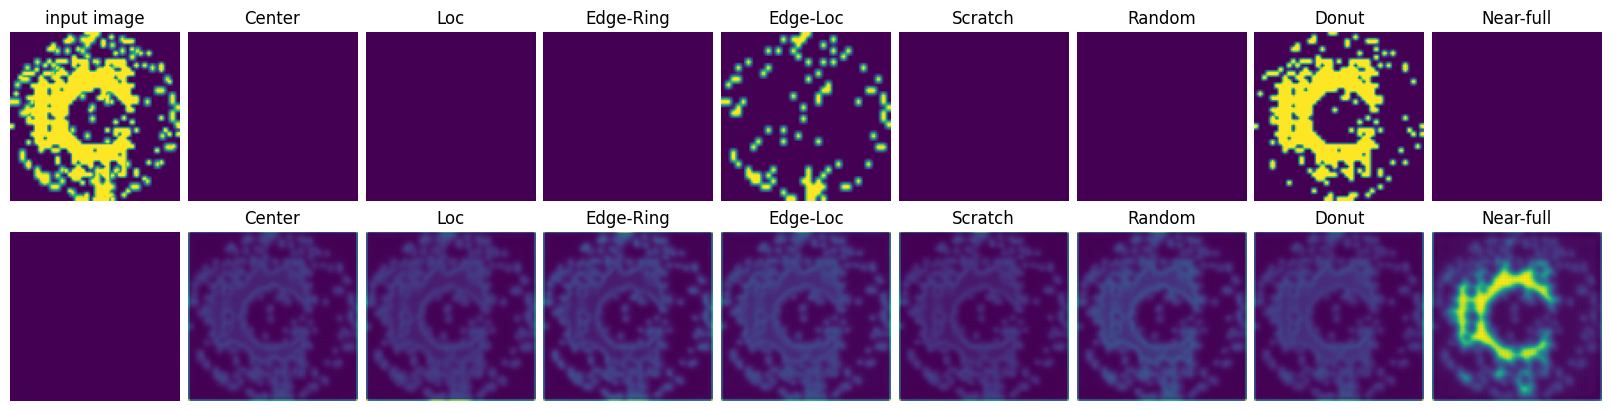

In [18]:
idx = 5
_,axs = plt.subplots(2,9, figsize=(16,4), layout='constrained')

axs[0,0].set_title('input image')
axs[0,0].imshow(in_batch[idx,:,:,0])
axs[1,0].imshow(np.zeros(wm811k.imsize))
for c in range(8):
    axs[0,c+1].set_title(WM_811K.defect_from_int[c])
    axs[0,c+1].imshow(out_batch[idx,:,:,c])
    axs[1,c+1].set_title(WM_811K.defect_from_int[c])
    axs[1,c+1].imshow(pred_batch[idx,:,:,c])

for ax in axs.flatten():
    ax.set_axis_off()

#plt.savefig(os.path.join('..', 'plots', 'segmentation_sample.png'))

In [40]:
class SpatialAttention(tf.keras.layers.Layer):

    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)

        self.conv = tf.keras.layers.Conv2D(
            filters=1,
            kernel_size=kernel_size,
            padding='same',
            activation='sigmoid',
            use_bias=False
        )

    def call(self, inputs):

        avg_pool = tf.reduce_mean(
            inputs,
            axis=-1,
            keepdims=True
        )

        max_pool = tf.reduce_max(
            inputs,
            axis=-1,
            keepdims=True
        )

        concat = tf.concat(
            [avg_pool, max_pool],
            axis=-1
        )

        attention_mask = self.conv(concat)

        return inputs * attention_mask

    def get_config(self):
        return super().get_config()

In [43]:
try:
    fullstack = load_model(
        "../models/multi_defect_fullstack.keras",
        custom_objects={
            "SpatialAttention": SpatialAttention
        },
        compile=False
    )
except Exception as e:
    import traceback
    traceback.print_exc()

print(type(fullstack))
print(fullstack.summary())

<class 'keras.src.models.sequential.Sequential'>


Model: "fullstack_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ segmentation_model (Functional) │ (None, 96, 96, 8)      │     3,210,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_model            │ (None, 8)              │     2,106,864 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,316,984 (20.28 MB)

 Trainable params: 5,311,800 (20.26 MB)

 Non-trainable params: 5,184 (20.25 KB)

None


In [44]:
for _ in range(20):

    x, _, y = wm811k._WM_811K__create_multi_defect_sample()

    pred = fullstack.predict(
        tf.expand_dims(x,0),
        verbose=0
    )[0]

    gt = [
        WM_811K.defect_from_int[i]
        for i,v in enumerate(y.numpy())
        if v > 0.5
    ]

    pr = [
        WM_811K.defect_from_int[i]
        for i,v in enumerate(pred)
        if v > 0.5
    ]

    print("GT =", gt)
    print("PR =", pr)
    print()

GT = []
PR = []

GT = ['Near-full']
PR = []

GT = ['Center', 'Edge-Loc', 'Scratch']
PR = []

GT = ['Near-full']
PR = []

GT = ['Edge-Loc', 'Donut']
PR = []

GT = ['Loc', 'Edge-Ring', 'Scratch']
PR = []

GT = ['Edge-Ring']
PR = ['Edge-Loc']

GT = ['Edge-Ring', 'Random']
PR = []

GT = ['Random']
PR = []

GT = ['Center', 'Scratch']
PR = []

GT = ['Scratch', 'Random']
PR = []

GT = ['Loc', 'Edge-Loc', 'Scratch']
PR = []

GT = ['Edge-Ring', 'Donut']
PR = []

GT = ['Edge-Ring', 'Edge-Loc']
PR = []

GT = []
PR = []

GT = ['Random']
PR = ['Random']

GT = ['Edge-Ring', 'Scratch']
PR = ['Edge-Loc']

GT = ['Random']
PR = []

GT = ['Near-full']
PR = []

GT = ['Edge-Ring', 'Scratch']
PR = []



/var/folders/s_/xyf3qgds0xj5stwts8yn4jn80000gn/T/ipykernel_12522/1443884350.py:13: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


GT=Loc        PRED=Near-full 
GT=Edge-Loc   PRED=Near-full 
GT=Edge-Loc   PRED=Near-full 
GT=Loc        PRED=Near-full 
GT=Edge-Loc   PRED=Near-full 
GT=Edge-Loc   PRED=Near-full 
GT=Loc        PRED=Near-full 
GT=Edge-Loc   PRED=Near-full 
GT=Center     PRED=Near-full 
GT=none       PRED=Near-full 
GT=none       PRED=Near-full 
GT=Edge-Ring  PRED=Near-full 
GT=Scratch    PRED=Near-full 
GT=Edge-Ring  PRED=Near-full 
GT=none       PRED=Near-full 
GT=none       PRED=Near-full 
GT=none       PRED=Near-full 
GT=Edge-Loc   PRED=Near-full 
GT=Edge-Loc   PRED=Near-full 
GT=none       PRED=Near-full 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step

Prediction statistics
Pred max : 0.20914112
Pred mean: 0.016078189

Channel scores
Center       mean=0.014468 max=0.134474
Loc          mean=0.013676 max=0.127632
Edge-Ring    mean=0.014439 max=0.120736
Edge-Loc     mean=0.015707 max=0.137824
Scratch      mean=0.012911 max=0.130632
Random       mean=0.017242 max=0.142590
Donut        mean=0.012488 max=0.1447

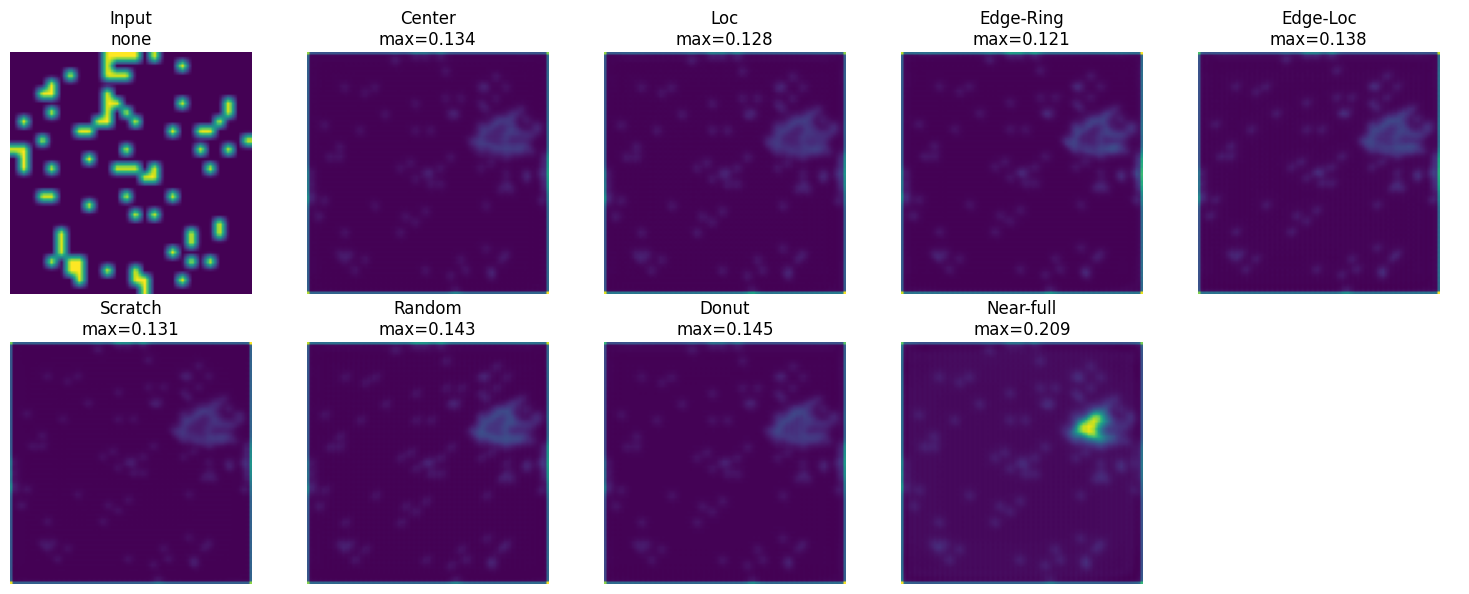

In [35]:
import pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from datasets import WM_811K

# ==========================================
# LOAD DATASET
# ==========================================

with open("../data/LSWMD_slimmed.pkl", "rb") as f:
    df = pickle.load(f)

for idx in range(20):

    row = df.iloc[idx]

    wafer = row["waferMap"]

    img = tf.convert_to_tensor(
        wafer,
        dtype=tf.float32
    )

    img = tf.squeeze(img)
    img = tf.expand_dims(img, -1)
    img = tf.maximum(img - 1.0, 0.0)
    img = tf.image.resize(img, (96,96))

    pred = seg_model.predict(
        tf.expand_dims(img,0),
        verbose=0
    )

    scores = pred[0].max(axis=(0,1))

    pred_class = labels[np.argmax(scores)]

    print(
        f"GT={row['label']:10s} "
        f"PRED={pred_class:10s}"
    )

# ==========================================
# LOAD MODEL
# ==========================================

seg_model = load_model(
    "../models/multi_defect_segmentation.keras",
    compile=False
)

# ==========================================
# PREDICT
# ==========================================

pred = seg_model.predict(img_batch)

print("\nPrediction statistics")
print("Pred max :", pred.max())
print("Pred mean:", pred.mean())

# ==========================================
# LABELS
# ==========================================

labels = [
    WM_811K.defect_from_int[i]
    for i in range(WM_811K.n_classes - 1)
]

# ==========================================
# CHANNEL SCORES
# ==========================================

print("\nChannel scores")

for c in range(8):

    mask = pred[0, :, :, c]

    print(
        f"{labels[c]:12s} "
        f"mean={mask.mean():.6f} "
        f"max={mask.max():.6f}"
    )

# ==========================================
# VISUALIZATION
# ==========================================

fig, axs = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

# Input image

axs[0,0].set_title(
    f"Input\n{row['label']}"
)

axs[0,0].imshow(
    img[:,:,0],
    cmap="viridis"
)

# Empty panel

axs[1,0].imshow(
    np.zeros((96,96))
)

axs[1,0].set_title("")

# Predicted masks

for c in range(8):

    r = (c + 1) // 5
    col = (c + 1) % 5

    mask = pred[0, :, :, c]

    axs[r,col].imshow(
        mask,
        cmap="viridis"
    )

    axs[r,col].set_title(
        f"{labels[c]}\nmax={mask.max():.3f}"
    )

for ax in axs.flatten():
    ax.axis("off")

plt.tight_layout()
plt.show()

In [36]:
corr = np.corrcoef(
    pred[0].reshape(-1,8).T
)

np.set_printoptions(
    precision=3,
    suppress=True
)

print(corr)

[[1.    0.987 0.99  0.988 0.991 0.983 0.988 0.758]
 [0.987 1.    0.991 0.988 0.985 0.982 0.991 0.742]
 [0.99  0.991 1.    0.989 0.994 0.99  0.989 0.731]
 [0.988 0.988 0.989 1.    0.981 0.981 0.996 0.764]
 [0.991 0.985 0.994 0.981 1.    0.988 0.982 0.736]
 [0.983 0.982 0.99  0.981 0.988 1.    0.987 0.792]
 [0.988 0.991 0.989 0.996 0.982 0.987 1.    0.784]
 [0.758 0.742 0.731 0.764 0.736 0.792 0.784 1.   ]]


reading wafermaps


  0%|          | 0/12822 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
GLOBAL STATISTICS
GT max   : 1.0
GT mean  : 0.050963268
Pred max : 0.20911902
Pred mean: 0.025217105

ACTIVE GT CHANNELS
Edge-Ring
Donut

PREDICTED CHANNELS
Center     mean=0.02177 max=0.13447
Loc        mean=0.02160 max=0.12763
Edge-Ring  mean=0.02295 max=0.12075
Edge-Loc   mean=0.02496 max=0.13782
Scratch    mean=0.01955 max=0.13064
Random     mean=0.02646 max=0.14259
Donut      mean=0.02072 max=0.14470
Near-full  mean=0.04373 max=0.20912

GT CHANNEL CORRELATION
[[  nan   nan   nan   nan   nan   nan   nan   nan]
 [  nan   nan   nan   nan   nan   nan   nan   nan]
 [  nan   nan 1.      nan   nan   nan 0.064   nan]
 [  nan   nan   nan   nan   nan   nan   nan   nan]
 [  nan   nan   nan   nan   nan   nan   nan   nan]
 [  nan   nan   nan   nan   nan   nan   nan   nan]
 [  nan   nan 0.064   nan   nan   nan 1.      nan]
 [  nan   nan   nan   nan   nan   nan   nan   nan]]

PREDICTION CHANNEL CORRELATION
[[1.    0.985 0.982 0.987 0.987 0.982 0.989 0.717]


/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


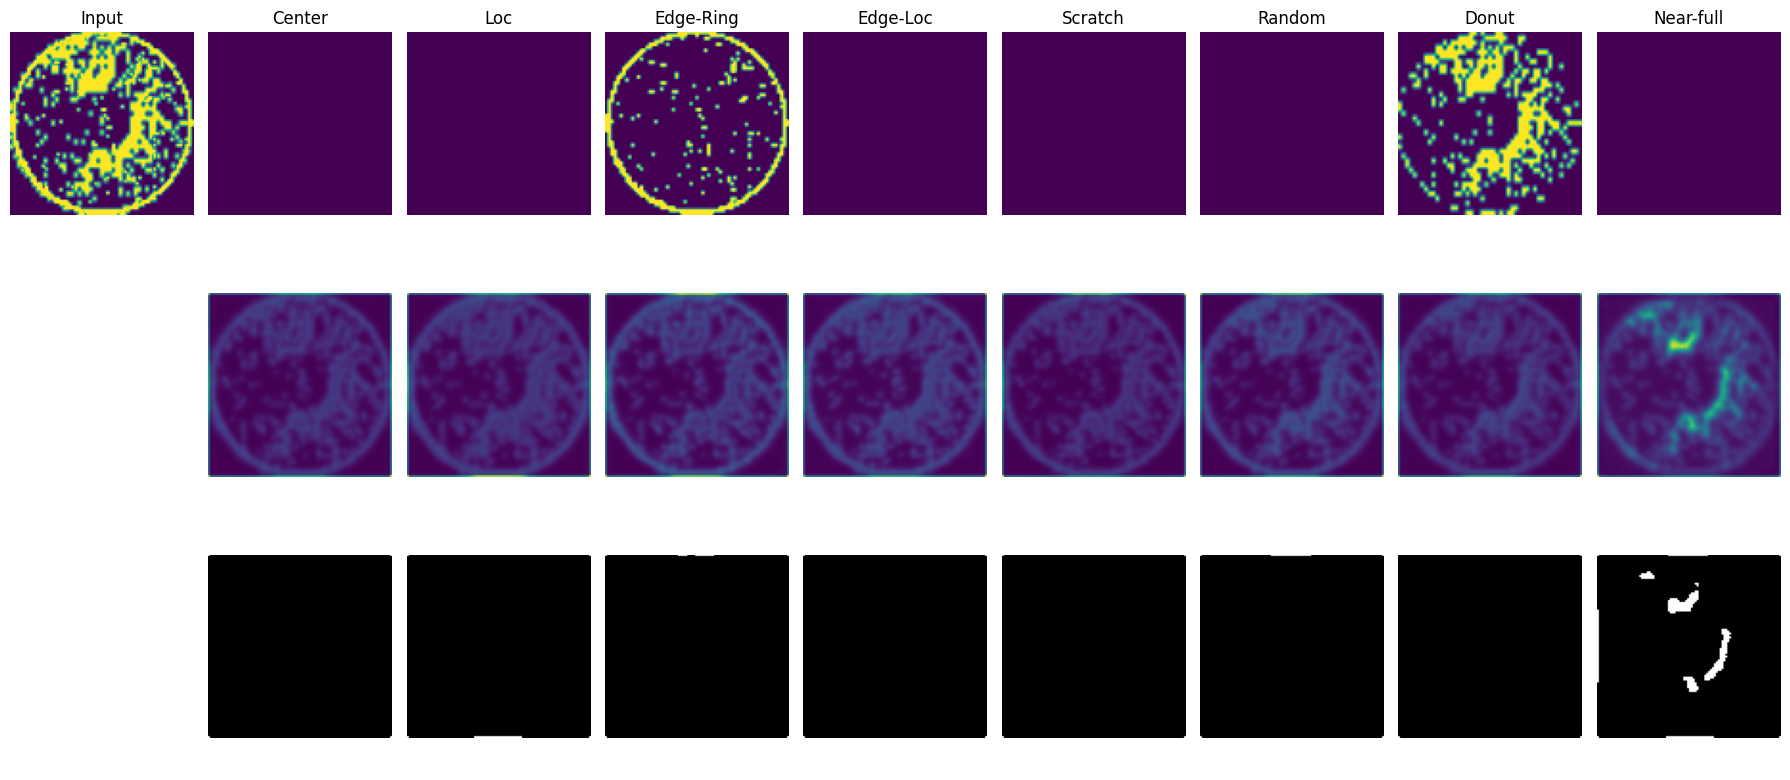

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

# ==========================================
# LOAD DATASET + MODEL
# ==========================================

from datasets import WM_811K

wm811k = WM_811K(imsize=(96,96))

seg_model = load_model(
    "../models/multi_defect_segmentation.keras",
    compile=False
)

# ==========================================
# GET ONE SAMPLE
# ==========================================

in_batch, out_batch = list(
    wm811k.dataset_multi_defect_segmentation()
    .batch(1)
    .take(1)
)[0]

pred_batch = seg_model.predict(in_batch)

gt = out_batch[0].numpy()
pred = pred_batch[0]

# ==========================================
# BASIC STATS
# ==========================================

print("="*50)
print("GLOBAL STATISTICS")
print("="*50)

print("GT max   :", gt.max())
print("GT mean  :", gt.mean())

print("Pred max :", pred.max())
print("Pred mean:", pred.mean())

# ==========================================
# ACTIVE GT CHANNELS
# ==========================================

print("\nACTIVE GT CHANNELS")

gt_active = np.where(
    gt.max(axis=(0,1)) > 0
)[0]

for c in gt_active:
    print(
        WM_811K.defect_from_int[c]
    )

# ==========================================
# PREDICTED CHANNELS
# ==========================================

print("\nPREDICTED CHANNELS")

for c in range(8):

    print(
        f"{WM_811K.defect_from_int[c]:10s}",
        f"mean={pred[:,:,c].mean():.5f}",
        f"max={pred[:,:,c].max():.5f}"
    )

# ==========================================
# GT CORRELATION
# ==========================================

gt_corr = np.corrcoef(
    gt.reshape(-1,8).T
)

print("\nGT CHANNEL CORRELATION")
print(np.round(gt_corr,3))

# ==========================================
# PRED CORRELATION
# ==========================================

pred_corr = np.corrcoef(
    pred.reshape(-1,8).T
)

print("\nPREDICTION CHANNEL CORRELATION")
print(np.round(pred_corr,3))

# ==========================================
# IOU FUNCTION
# ==========================================

def iou(gt_mask, pred_mask, thr=0.1):

    gt_mask = gt_mask > 0.5
    pred_mask = pred_mask > thr

    intersection = np.logical_and(
        gt_mask,
        pred_mask
    ).sum()

    union = np.logical_or(
        gt_mask,
        pred_mask
    ).sum()

    return intersection / (union + 1e-8)

# ==========================================
# PER CHANNEL IOU
# ==========================================

print("\nIOU SCORES")

for c in range(8):

    score = iou(
        gt[:,:,c],
        pred[:,:,c]
    )

    print(
        f"{WM_811K.defect_from_int[c]:10s}",
        f"{score:.4f}"
    )

# ==========================================
# VISUALIZATION
# ==========================================

fig, axs = plt.subplots(
    3,
    9,
    figsize=(18,8)
)

axs[0,0].imshow(
    in_batch[0,:,:,0],
    cmap="viridis"
)
axs[0,0].set_title("Input")

axs[1,0].axis("off")
axs[2,0].axis("off")

for c in range(8):

    axs[0,c+1].set_title(
        WM_811K.defect_from_int[c]
    )

    axs[0,c+1].imshow(
        gt[:,:,c],
        cmap="viridis"
    )

    axs[1,c+1].imshow(
        pred[:,:,c],
        cmap="viridis"
    )

    axs[2,c+1].imshow(
        pred[:,:,c] > 0.1,
        cmap="gray"
    )

for ax in axs.flatten():
    ax.axis("off")

plt.tight_layout()
plt.show()

In [38]:
for i in range(20):

    x, y = next(
        iter(
            wm811k.dataset_multi_defect_segmentation()
            .batch(1)
        )
    )

    active = np.where(
        y[0].numpy().max(axis=(0,1)) > 0
    )[0]

    print(
        [WM_811K.defect_from_int[c]
         for c in active]
    )

['Edge-Ring', 'Donut']
['Edge-Loc']
['Edge-Ring', 'Donut']
['Loc', 'Edge-Ring', 'Donut']
['Center', 'Loc']
['Edge-Ring', 'Edge-Loc']
['Center', 'Loc']
[]
[]
['Center', 'Donut']
['Edge-Ring']
['Loc', 'Edge-Loc']
['Center', 'Edge-Loc']
['Loc', 'Edge-Loc', 'Donut']
['Loc', 'Scratch', 'Donut']
['Loc']
['Random']
['Center']
['Edge-Loc']
[]
